## CNN para clasificar espacios de parqueo

### Importar bibliotecas

In [1]:
from pathlib import Path


import matplotlib.pyplot as plt
import numpy as np

import tensorflow as tf
from tensorflow.keras import layers
import keras_tuner as kt
import tensorboard

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


### Cargar y dividir el dataset: 70% train, 15% validation y 15% test

In [2]:
DATASET_DIR = Path("dataset")
CLASS_NAMES = ["0_Parqueo", "1_Parqueo"]
IMG_SIZE = (128, 128)
BATCH_SIZE = 16
SEED = 42

dataset_completo = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=None,
    shuffle=False,
)

total_imagenes = tf.data.experimental.cardinality(dataset_completo).numpy()

dataset_completo = dataset_completo.shuffle(
    total_imagenes,
    seed=SEED,
    reshuffle_each_iteration=False,
)

cantidad_train = int(total_imagenes * 0.70)
cantidad_restante = total_imagenes - cantidad_train
cantidad_val = cantidad_restante // 2
cantidad_test = cantidad_restante - cantidad_val

train_raw = dataset_completo.take(cantidad_train)
restante = dataset_completo.skip(cantidad_train)
val_raw = restante.take(cantidad_val)
test_raw = restante.skip(cantidad_val)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = (
    train_raw
    .cache()
    .shuffle(cantidad_train, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
val_ds = val_raw.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = test_raw.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)

print(f"Total: {total_imagenes}")
print(f"Train: {cantidad_train} ({cantidad_train / total_imagenes:.1%})")
print(f"Validation: {cantidad_val} ({cantidad_val / total_imagenes:.1%})")
print(f"Test: {cantidad_test} ({cantidad_test / total_imagenes:.1%})")

Found 250 files belonging to 2 classes.
Total: 250
Train: 175 (70.0%)
Validation: 37 (14.8%)
Test: 38 (15.2%)


### Data augmentation
Estas transformaciones se ejecutan solamente durante el entrenamiento porque se incluyen dentro de la CNN.

In [3]:
def crear_data_augmentation():
    return tf.keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.20),
            layers.RandomContrast(0.20),
        ],
        name="data_augmentation",
    )

data_augmentation = crear_data_augmentation()

### Modelo CNN y espacio de hiperparametros

In [4]:
def build_model(hp):
    
    input_red = layers.Input(
        shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
        name="input_imagen",
    )

    x = crear_data_augmentation()(input_red)
    x = layers.Rescaling(1.0 / 255, name="normalizacion")(x)

    x = layers.Conv2D(32, (3, 3), activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation="relu")(x)
    x = layers.Flatten()(x)

    cantidad_dense = hp.Int("cantidad_dense", min_value=1, max_value=3)
    for indice in range(cantidad_dense):
        unidades = hp.Choice(
            f"unidades_dense_{indice + 1}",
            values=[32, 64, 128, 256],
        )
        x = layers.Dense(unidades, activation="relu")(x)

    output_red = layers.Dense(1, activation="sigmoid", name="salida")(x)
    model = tf.keras.Model(inputs=input_red, outputs=output_red)

    learning_rate = hp.Choice(
        "learning_rate",
        values=[1e-2, 1e-3, 1e-4],
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return model

### Random Search con Keras Tuner

In [5]:
tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective=kt.Objective("val_accuracy", direction="max"),
    max_trials=10,
    executions_per_trial=1,
    directory="keras_tuner_results",
    project_name="cnn_parqueos",
    overwrite=True,
    seed=SEED,
)

tuner.search_space_summary()

early_stopping_tuner = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

tuner.search(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping_tuner],
    shuffle=False,
    verbose=1,
)

Trial 10 Complete [00h 00m 03s]
val_accuracy: 0.4864864945411682

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 00m 52s


### Construir y entrenar el mejor modelo

In [6]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Mejores hiperparametros:")
print("Learning rate:", best_hp.get("learning_rate"))
print("Cantidad de capas Dense:", best_hp.get("cantidad_dense"))
for indice in range(best_hp.get("cantidad_dense")):
    print(
        f"Unidades Dense {indice + 1}:",
        best_hp.get(f"unidades_dense_{indice + 1}"),
    )

best_model = tuner.hypermodel.build(best_hp)

early_stopping_final = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

history = best_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping_final],
    shuffle=False,
    verbose=1,
)

best_model.summary()

Mejores hiperparametros:
Learning rate: 0.001
Cantidad de capas Dense: 2
Unidades Dense 1: 32
Unidades Dense 2: 32
Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.5314 - loss: 0.7394 - val_accuracy: 0.4865 - val_loss: 0.6542
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8114 - loss: 0.4257 - val_accuracy: 0.9730 - val_loss: 0.1645
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9714 - loss: 0.0962 - val_accuracy: 0.8919 - val_loss: 0.3339
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9371 - loss: 0.2054 - val_accuracy: 1.0000 - val_loss: 0.0084
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9829 - loss: 0.1123 - val_accuracy: 1.0000 - val_loss: 0.0278
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9657 - loss: 0.0981 - val_accuracy: 1.0000 - val_loss: 0.0358
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9829 - loss: 0.0441 - val_accuracy: 1.0000 - val_loss: 0.0

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_imagen (InputLayer)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalizacion (Rescaling)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │     3,211,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,916,901 (37.83 MB)

 Trainable params: 3,305,633 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,611,268 (25.22 MB)

### Graficas del entrenamiento del mejor modelo

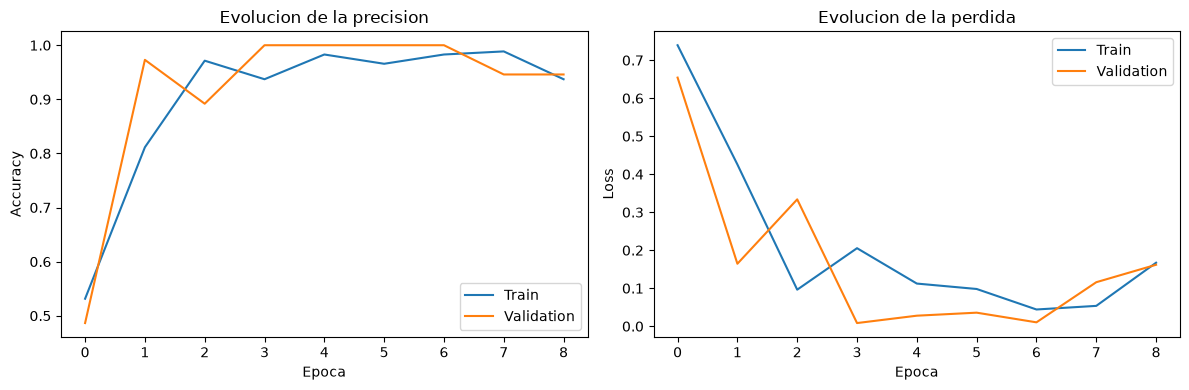

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Evolucion de la precision")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Evolucion de la perdida")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### Evaluacion final con test

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9737 - loss: 0.0298 
Test loss: 0.0298
Test accuracy: 0.9737


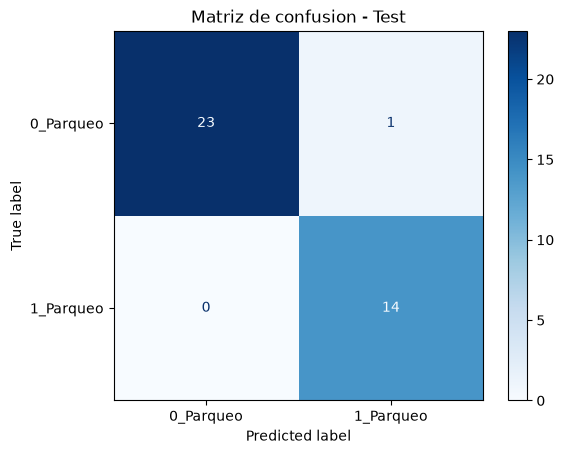

              precision    recall  f1-score   support

   0_Parqueo       1.00      0.96      0.98        24
   1_Parqueo       0.93      1.00      0.97        14

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38



In [8]:
test_loss, test_accuracy = best_model.evaluate(test_ds, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

y_pred_prob = best_model.predict(test_ds, verbose=0).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)
y_true = np.concatenate(
    [labels.numpy().ravel() for _, labels in test_ds]
).astype(int)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES,
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusion - Test")
plt.show()

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=CLASS_NAMES,
        zero_division=0,
    )
)